In [2]:
import pandas as Dimen_ReductPn
import warnings as Dimen_ReductWn
Dimen_ReductWn.filterwarnings("ignore")

Runtime crashed after vectorization. So taking 2000 data for implementation without dimensionality reduction.

In [3]:
Dimen_Reduct = Dimen_ReductPn.read_csv('TextData_DimensionalityReduction.csv',nrows=2000)

In [4]:
Dimen_Reduct['category'].value_counts()

,count
category,
POLITICS,713
ENTERTAINMENT,479
COMEDY,133
WORLD NEWS,116
BLACK VOICES,105
QUEER VOICES,97
MEDIA,62
CRIME,59
WEIRD NEWS,57


In [5]:
Dimen_top3_catgory = Dimen_Reduct['category'].value_counts().nlargest(3).index
Dimen_Reduct = Dimen_Reduct[Dimen_Reduct['category'].isin(Dimen_top3_catgory)]

In [6]:
from sklearn.preprocessing import LabelEncoder as DimenRedctEn
DimenRedctenc = DimenRedctEn()
Dimen_Reduct['category'] = DimenRedctenc.fit_transform(Dimen_Reduct['category'])
Dimen_Reduct['category'].value_counts()

,count
category,
2,713
1,479
0,133


In [7]:
Dimen_Reduct

,short_description,category
1,course song,1
2,actor longtime girlfriend anna eberstein tied ...,1
3,actor gives dems ass kicking fighting hard eno...,1
4,dietland actress said using bags really cathar...,1
5,right equate horrific incidents sexual assault...,1
...,...,...
1993,know first instinct hate,0
1994,purple one estate released song previously uns...,1
1996,using words president may understand,0
1997,late show host finds hidden meaning trump tweet,0


In [8]:
DimenRedctXa = Dimen_Reduct.drop(['category'], axis=1)
DimenRedctYa = Dimen_Reduct['category']

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer as DimenRedctTfdVzr
DimenRedctVtrzr = DimenRedctTfdVzr(analyzer='word', ngram_range=(1, 1))
DimenRedctXa = DimenRedctVtrzr.fit_transform(Dimen_Reduct['short_description'].values.astype('U')).toarray()
print("Shape of the vectorized input data:",DimenRedctXa.shape)

Shape of the vectorized input data: (1325, 4401)


In [10]:
###@@@@--- using  SparsePCA Dimensionaly Reduction----###@@@

from sklearn.decomposition import SparsePCA as Dimen_ReductSPRPCA
import numpy as Dimen_Reductnu
import matplotlib.pyplot as Dimen_ReductMn

dimenrdsprpca = Dimen_ReductSPRPCA(n_components=3, random_state=25)
DimenRedctXa = dimenrdsprpca.fit_transform(DimenRedctXa)
DimenRedctXa.shape

(1325, 3)

In [11]:
DimenRedctXa

array([[-0.00771246, -0.01770028, -0.01573255],
       [-0.00771246, -0.01770028, -0.01573255],
       [-0.00771246, -0.01770028,  0.15452477],
       ...,
       [-0.00771246, -0.01770028, -0.01573255],
       [ 0.26356336, -0.01770028,  0.19199589],
       [-0.00771246,  0.16207903, -0.01573255]])

In [12]:
from imblearn.over_sampling import SMOTE as Dimen_ReductSM
from collections import Counter as Dimen_ReductCCnt

print("Unbalanced Class Distribution:")
print(Dimen_Reduct['category'].value_counts())

###@@@ ---- Oversampling process of Smote using Text data ----###@@@
print("\n+=== Oversampling Process Using SMOTE ====+")
print('Text Data  %s' % Dimen_ReductCCnt(DimenRedctYa))
Dimenredmd= Dimen_ReductSM()
DimenRedctXa, DimenRedctYa = Dimenredmd.fit_resample(DimenRedctXa, DimenRedctYa)
print('Oversampled  %s' % Dimen_ReductCCnt(DimenRedctYa))

Dimen_Reduct = Dimen_ReductPn.DataFrame(DimenRedctXa, columns=[f'component_{i}' for i in range(DimenRedctXa.shape[1])])
Dimen_Reduct['category'] = DimenRedctYa

print("\nBalanced Class Distribution:")
print(Dimen_Reduct['category'].value_counts())

Unbalanced Class Distribution:
category
2    713
1    479
0    133
Name: count, dtype: int64

+=== Oversampling Process Using SMOTE ====+
Text Data  Counter({2: 713, 1: 479, 0: 133})
Oversampled  Counter({1: 713, 2: 713, 0: 713})

Balanced Class Distribution:
category
1    713
2    713
0    713
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split as Dimen_Reducttspt

###@@@@ ---- split the data into Training 60%, val 20%, test 20% ----###@@@
DimenRedctXatrn, DimenRedctXatst, DimenRedctYatrn, DimenRedctYatst = Dimen_Reducttspt(DimenRedctXa, DimenRedctYa, test_size=0.2, random_state=10)
print("Shape of Train data (Text features)  :", DimenRedctXatrn.shape)

Shape of Train data (Text features)  : (1711, 3)


In [14]:
DimenRedctXavl, DimenRedctXatst, DimenRedctYavl, DimenRedctYatst = Dimen_Reducttspt(DimenRedctXatst, DimenRedctYatst, test_size=0.5, random_state=10)

print("Shape of Val data (Text features)  :", DimenRedctXavl.shape)
print("Shape of Test data (Text features)  :", DimenRedctXatst.shape)

Shape of Val data (Text features)  : (214, 3)
Shape of Test data (Text features)  : (214, 3)


In [15]:
import time as Dimen_Reductm
from sklearn import metrics as Dimen_Reductmcs
from sklearn.model_selection import GridSearchCV as Dimen_Reductgrdsh
from sklearn.metrics import confusion_matrix as Dimen_Reductcnmx
import matplotlib.pyplot as Dimen_ReductMn
from sklearn.metrics import ConfusionMatrixDisplay as Dimen_Reductcnmxdp
from sklearn.metrics import classification_report as Dimen_Reductrpt
from sklearn.preprocessing import label_binarize as Dimen_Reductlb
from sklearn.metrics import auc as DimenRedtAuc
from sklearn.metrics import roc_curve as DimenRedtrcr

#Logistic Regression Classifier

In [16]:
from sklearn.linear_model import LogisticRegression as Dimen_ReductLrc

Dimen_Reducthyprms = {
                       'penalty' : ['l2'],
                       'C' : [0.1, 0.01, 0.5, 0.8, 1.0],
                       'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag']
                      }

Dimenredmd = Dimen_ReductLrc()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:400], DimenRedctYatrn[:400])
print("best Params -- LR:")
print(Dimenredmd.best_params_)

best Params -- LR:
{'C': 0.5, 'penalty': 'l2', 'solver': 'newton-cg'}


In [17]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductLrc(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--LR classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--LR classifier   : 0.016756296157836914 



              precision    recall  f1-score   support

           0       0.90      0.13      0.23        69
           1       0.40      0.88      0.55        77
           2       0.59      0.29      0.39        68

    accuracy                           0.45       214
   macro avg       0.63      0.44      0.39       214
weighted avg       0.62      0.45      0.40       214


Validate Time--LR Classifier : 0.05086064338684082 



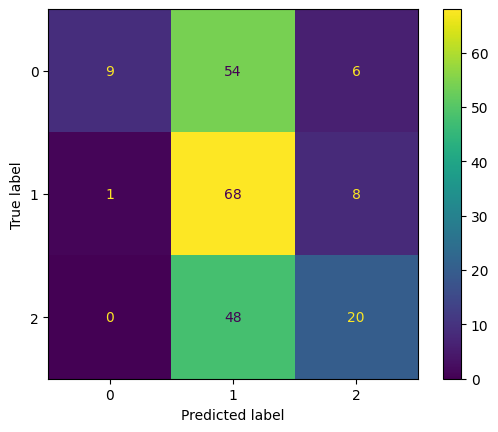

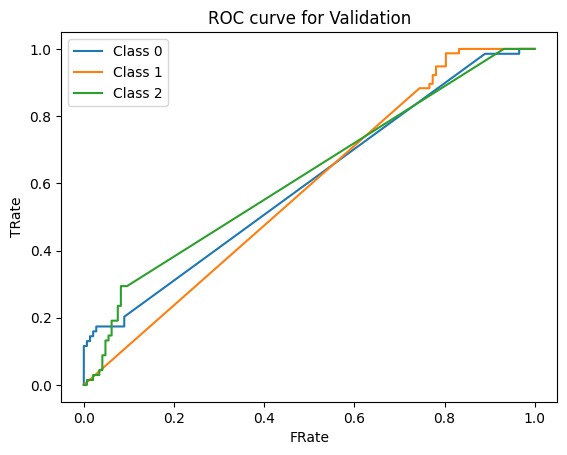


AUC Validation Metric:  0.5996311009771609


In [18]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--LR Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYavl_bin.shape[1]

for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.82      0.14      0.24        65
           1       0.44      0.94      0.59        82
           2       0.58      0.22      0.32        67

    accuracy                           0.47       214
   macro avg       0.61      0.43      0.38       214
weighted avg       0.60      0.47      0.40       214


Test Time--LR Classifier : 0.0599520206451416 



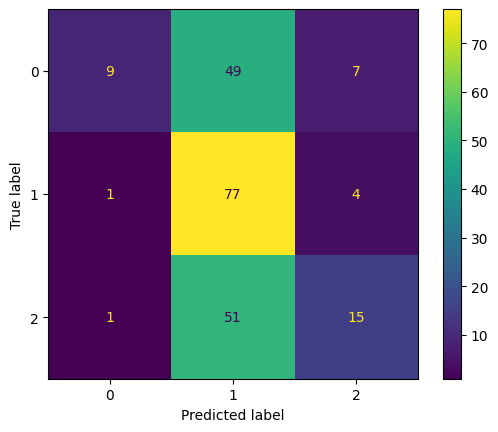

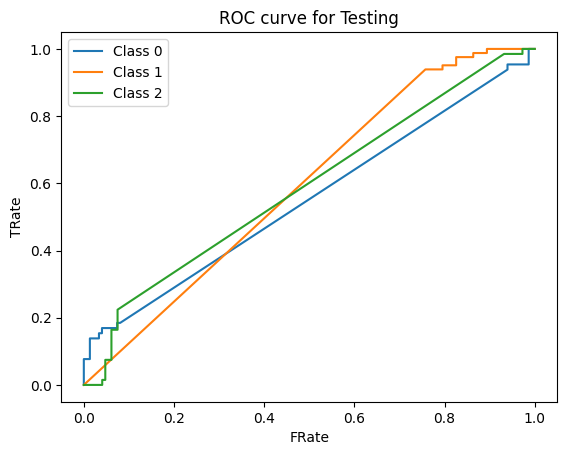


AUC Testing Metric:  0.5781089637879194


In [19]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--LR Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYatst_bin.shape[1]

###@@@--- Calculate ROC curve for each class
for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)

#Decision Tree Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier as Dimen_ReductDTC

Dimen_Reducthyprms = {
                       'criterion' : ['gini', 'entropy', 'log_loss'],
                       'splitter' : ['best', 'random'],
                       'max_depth' : [1, 5, 10, 50, None]
                       }

Dimenredmd = Dimen_ReductDTC()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:5000], DimenRedctYatrn[:5000])
print("best Params -- DT:")
print(Dimenredmd.best_params_)

best Params -- DT:
{'criterion': 'gini', 'max_depth': 5, 'splitter': 'best'}


In [21]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductDTC(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--DT classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--DT classifier   : 0.010452032089233398 



              precision    recall  f1-score   support

           0       0.75      0.13      0.22        69
           1       0.39      0.88      0.54        77
           2       0.57      0.24      0.33        68

    accuracy                           0.43       214
   macro avg       0.57      0.42      0.37       214
weighted avg       0.56      0.43      0.37       214


Validate Time--DT Classifier : 0.018517732620239258 



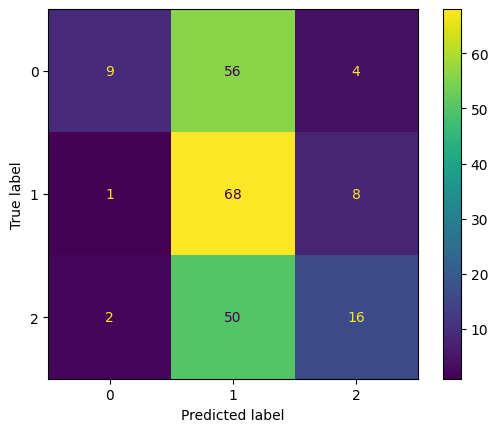

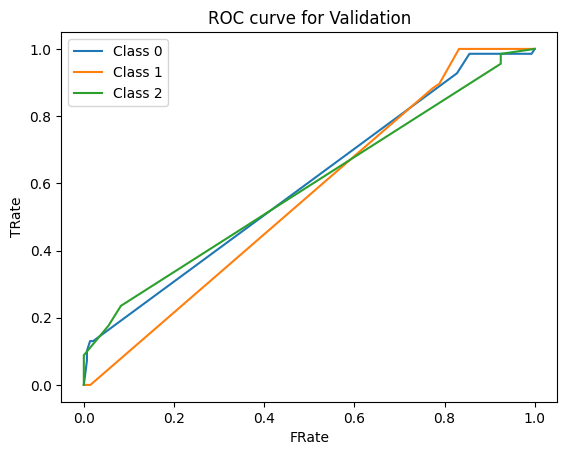


AUC Validation Metric:  0.5816611394230016


In [22]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--DT Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYavl_bin.shape[1]

for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.80      0.12      0.21        65
           1       0.43      0.94      0.59        82
           2       0.52      0.19      0.28        67

    accuracy                           0.46       214
   macro avg       0.58      0.42      0.36       214
weighted avg       0.57      0.46      0.38       214


Test Time--DT Classifier : 0.016859054565429688 



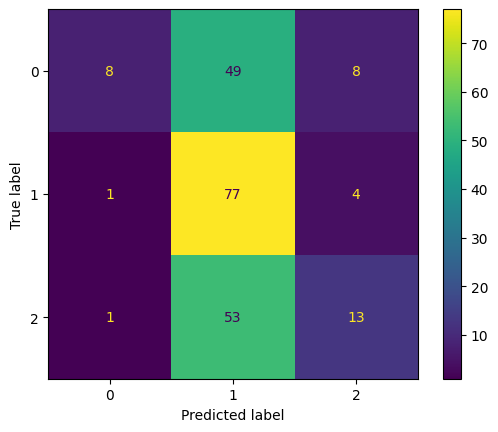

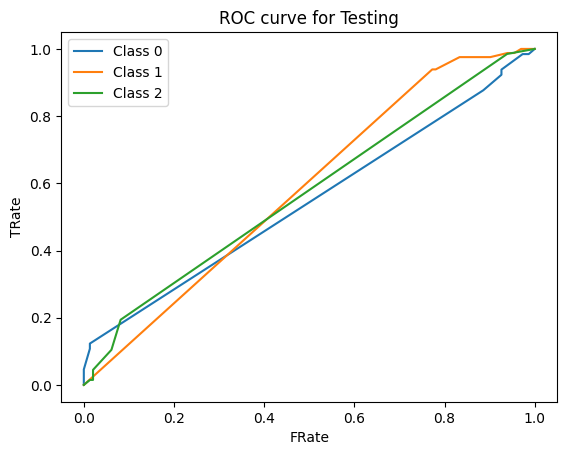


AUC Testing Metric:  0.5674456176962092


In [23]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--DT Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYatst_bin.shape[1]

###@@@--- Calculate ROC curve for each class
for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)

#Balanced Random Forest Classifier

In [24]:
from imblearn.ensemble import BalancedRandomForestClassifier as Dimen_ReductBRF


Dimen_Reducthyprms = {
                       'n_estimators' : [10, 50, 100, 200],
                       'criterion' : ['gini', 'entropy', 'log_loss'],
                       'max_depth' : [1, 5, 50, None],
                       'max_features': [None, 'sqrt', 'log2']
                       }

Dimenredmd = Dimen_ReductBRF()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:5000], DimenRedctYatrn[:5000])
print("best Params -- BRF:")
print(Dimenredmd.best_params_)

best Params -- BRF:
{'criterion': 'gini', 'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}


In [25]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductBRF(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--BRF classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--BRF classifier   : 0.38166046142578125 



              precision    recall  f1-score   support

           0       0.83      0.14      0.25        69
           1       0.40      0.88      0.55        77
           2       0.60      0.26      0.37        68

    accuracy                           0.45       214
   macro avg       0.61      0.43      0.39       214
weighted avg       0.60      0.45      0.39       214


Validate Time--BRF Classifier : 0.026618242263793945 



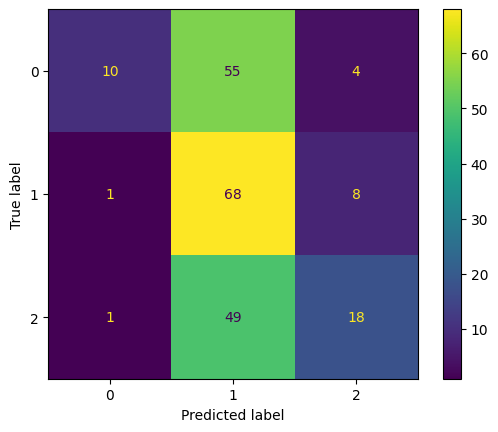

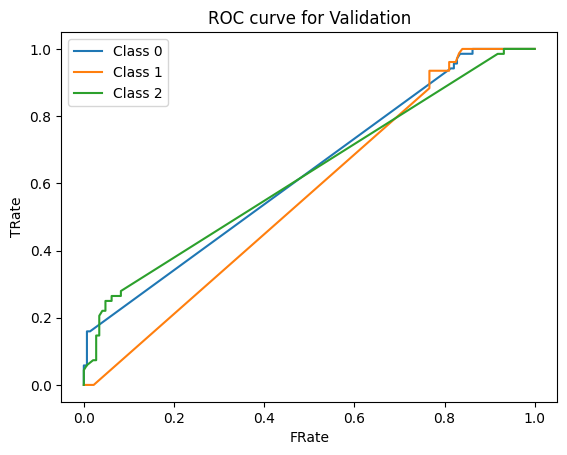


AUC Validation Metric:  0.6035716764962543


In [26]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--BRF Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYavl_bin.shape[1]

for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.83      0.15      0.26        65
           1       0.44      0.94      0.59        82
           2       0.60      0.22      0.33        67

    accuracy                           0.48       214
   macro avg       0.62      0.44      0.39       214
weighted avg       0.61      0.48      0.41       214


Test Time--BRF Classifier : 0.0221560001373291 



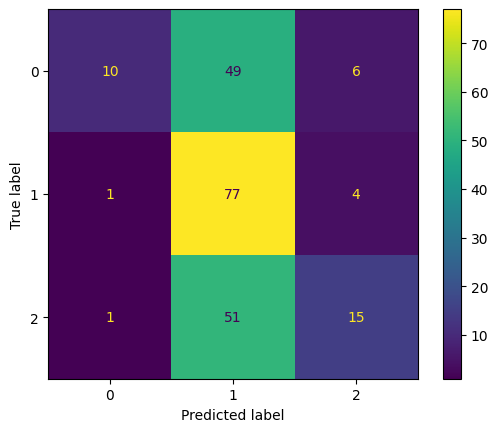

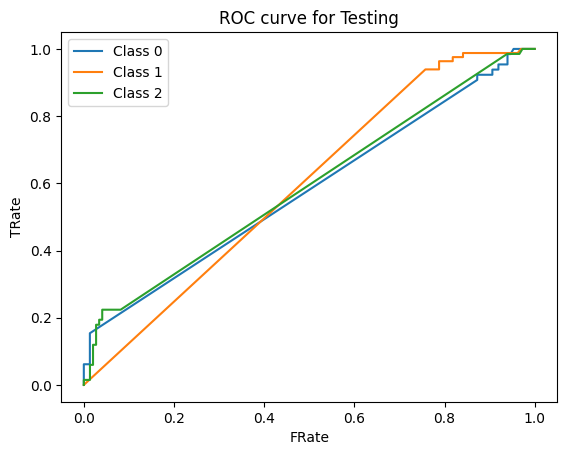


AUC Testing Metric:  0.588294457390418


In [27]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--BRF Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
dimen_clas = DimenRedctYatst_bin.shape[1]

###@@@--- Calculate ROC curve for each class
for d in range(dimen_clas):
    dimfp, dimtp, dimth = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, d], dimenrdcpr_probs[:, d])
    Dimen_ReductMn.plot(dimfp, dimtp, label=f'Class {Dimenredmd.classes_[d]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)